In [1]:
import os
import netket as nk
import jax
from netket.operator.spin import sigmax, sigmaz

os.environ["JAX_PLATFORM_NAME"] = "cpu"
N = 20
hi = nk.hilbert.Spin(s=1 / 2, N=N)
hi.random_state(jax.random.key(0), 3)
Gamma = -1
H = sum([Gamma * sigmax(hi, i) for i in range(N)])

/opt/miniconda3/envs/NQS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sp_h = H.to_sparse()
sp_h.shape

(1048576, 1048576)

In [3]:
from scipy.sparse.linalg import eigsh

eig_vals, eig_vecs = eigsh(sp_h, k=2, which="SA")

print("eigenvalues with scipy sparse:", eig_vals)

E_gs = eig_vals[0]

eigenvalues with scipy sparse: [-20. -18.]


In [4]:
# numerical operations in the model should always use jax.numpy
# instead of numpy because jax supports computing derivatives.
# If you want to better understand the difference between the two, check
# https://flax.readthedocs.io/en/latest/notebooks/jax_for_the_impatient.html
import jax.numpy as jnp

# Flax is a framework to define models using jax
import flax

# Flax has two 'neural network' libraries. THe  first one is `flax.linen`
# which has been in use since 2020, and most examples use it. The new one,
# nnx, is somewhat simpler to use, and it's the one we will use here.
from flax import nnx


# An NNX model must be a class subclassing `nnx.Module`
class MF(nnx.Module):
    """
    A class implementing a uniform mean-field model.
    """

    # The __init__ function is used to define the parameters of the model
    # The RNG argument is used to initialize the parameters of the model.
    def __init__(self, *, rngs: nnx.Rngs):
        # To generate random numbers we need to extract the key from the
        # `rngs` object.
        key = rngs.params()
        # We store the log-wavefunction on a single site, and we call it
        # `log_phi_local`. This is a variational parameter, and it will be
        # optimized during training.
        #
        # We store a single real parameter, as we assume the wavefunction
        # is normalised, and initialise it according to a normal distibution.
        self.log_phi_local = nnx.Param(jax.random.normal(key, (1,)))

    # The __call__(self, x) function should take as
    # input a batch of states x.shape = (n_samples, L)
    # and should return a vector of n_samples log-amplitudes
    def __call__(self, x: jax.Array):

        # compute the probabilities
        p = nnx.log_sigmoid(self.log_phi_local * x)

        # sum the output
        return 0.5 * jnp.sum(p, axis=-1)

In [5]:
# Create an instance of the model, using the seed 0
mf_model = MF(rngs=nnx.Rngs(0))
# If you want to learn more about how to use this model, check the nnx tutorial
# https://flax.readthedocs.io/en/latest/nnx_basics.html

# Create the local sampler on the hilbert space
sampler = nk.sampler.MetropolisLocal(hi)

# Construct the variational state using the model and the sampler above.
# n_samples specifies how many samples should be used to compute expectation
# values.
vstate = nk.vqs.MCState(sampler, mf_model, n_samples=512)

In [6]:
print(vstate.parameters)

{'log_phi_local': Array([1.88002989], dtype=float64)}


In [7]:
E = vstate.expect(H)
print(E)

-13.42 ± 0.15 [σ²=11.51, R̂=1.0483]


In [8]:
print("Mean                  :", E.mean)
print("Error                 :", E.error_of_mean)
print("Variance              :", E.variance)
print("Convergence indicator :", E.R_hat)
print("Correlation time      :", E.tau_corr)

Mean                  : -13.422366762420923
Error                 : 0.14993717103263088
Variance              : 11.510351491721421
Convergence indicator : 1.0482814480901217
Correlation time      : 0.0


In [9]:
vstate.expect_and_grad(H)

(-13.42 ± 0.15 [σ²=11.51, R̂=1.0483],
 {'log_phi_local': Array([5.30578214], dtype=float64)})

In [10]:
from tqdm import tqdm

energy_history = []
n_steps = 100

# For every iteration (tqdm is just a progress bar)
for i in tqdm(range(n_steps)):
    # compute energy and gradient of the energy
    E, E_grad = vstate.expect_and_grad(H)
    # log the energy to a list
    energy_history.append(E.mean.real)
    # equivalent to vstate.parameters - 0.05*E_grad , but it performs this
    # function on every leaf of the dictionaries containing the set of parameters
    new_pars = jax.tree_util.tree_map(
        lambda x, y: x - 0.05 * y, vstate.parameters, E_grad
    )
    # actually update the parameters
    vstate.parameters = new_pars

100%|██████████| 100/100 [00:00<00:00, 140.17it/s]


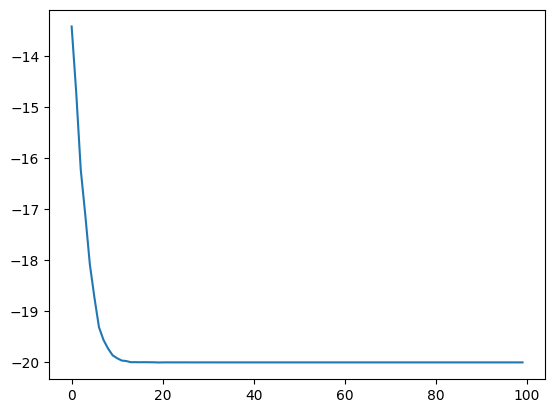

In [11]:
import matplotlib.pyplot as plt

plt.plot(energy_history)

In [12]:
# First we reset the parameters to run the optimisation again
vstate.init_parameters()

# Then we create an optimiser from the standard library.
# You can also use optax.
optimizer = nk.optimizer.Sgd(learning_rate=0.05)

# build the optimisation driver
gs = nk.driver.VMC(H, optimizer, variational_state=vstate)

# run the driver for 300 iterations. This will display a progress bar
# by default.
gs.run(n_iter=300)

mf_energy = vstate.expect(H)
error = abs((mf_energy.mean - eig_vals[0]) / eig_vals[0])
print("Optimized energy and relative error: ", mf_energy, error)

100%|██████████| 300/300 [00:02<00:00, 141.60it/s, Energy=-2.000e+01 ± nan [σ²=0.000e+00]]                    


Optimized energy and relative error:  -2.000e+01 ± nan [σ²=0.000e+00] 3.552713678800502e-16


In [13]:
# we can also inspect the parameter:
print("Final optimized parameter: ", vstate.parameters["log_phi_local"])

Final optimized parameter:  [-5.21604542e-17]


In [14]:
eig_vals[0]

-19.999999999999993

In [15]:
class JasShort(nnx.Module):

    def __init__(self, *, rngs: nnx.Rngs):

        # Define two parameters j1, and j2.
        # Initialise them with a random normal distribution of standard deviation
        # 0.01
        # We must get a different key for each parameter, otherwise they will be
        # initialised with the same value.
        self.j1 = nnx.Param(0.01 * jax.random.normal(rngs.params(), (1,)), dtype=float)
        self.j2 = nnx.Param(0.01 * jax.random.normal(rngs.params(), (1,)), dtype=float)

    def __call__(self, x: jax.Array):

        # compute the nearest-neighbor correlations
        corr1 = x * jnp.roll(x, -1, axis=-1)
        corr2 = x * jnp.roll(x, -2, axis=-1)

        # sum the output
        return jnp.sum(self.j1 * corr1 + self.j2 * corr2, axis=-1)


# Initialise the model wtih seed 1
model = JasShort(rngs=nnx.Rngs(1))

vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

In [16]:
optimizer = nk.optimizer.Sgd(learning_rate=0.01)

gs = nk.driver.VMC(
    H,
    optimizer,
    variational_state=vstate,
    preconditioner=nk.optimizer.SR(diag_shift=0.1),
)

# construct the logger
log = nk.logging.RuntimeLog()

# One or more logger objects must be passed to the keyword argument `out`.
gs.run(n_iter=300, out=log)

print(
    f"Final optimized parameters: j1={vstate.parameters['j1']}, j2={vstate.parameters['j2']}"
)

jas_energy = vstate.expect(H)
error = abs((jas_energy.mean - eig_vals[0]) / eig_vals[0])
print(f"Optimized energy : {jas_energy}")
print(f"relative error   : {error}")

100%|██████████| 300/300 [00:02<00:00, 130.45it/s, Energy=-2.000e+01 ± 1.292e-13 [σ²=1.683e-23, R̂=1.0081]]    


Final optimized parameters: j1=[1.72867057e-13], j2=[1.13681903e-13]
Optimized energy : -2.000e+01 ± 1.198e-13 [σ²=1.447e-23, R̂=1.0050]
relative error   : 3.019806626980427e-15


In [17]:
data_jastrow = log.data
print(data_jastrow)

HistoryDict with 2 elements:
	'Energy' -> History(keys=['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], n_iters=300)
	'acceptance' -> History(keys=['value'], n_iters=300)


Text(0, 0.5, 'Energy')

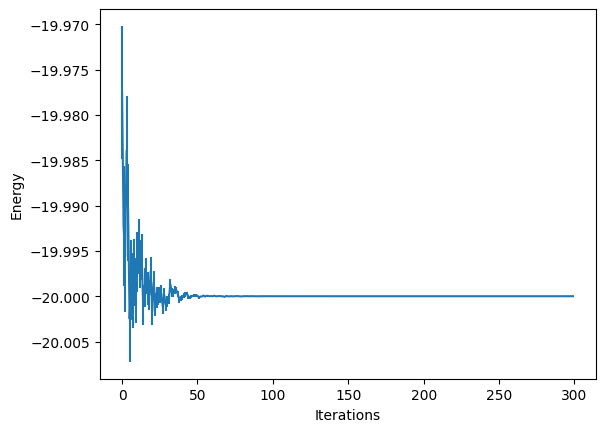

In [18]:
from matplotlib import pyplot as plt

plt.errorbar(
    data_jastrow["Energy"].iters,
    data_jastrow["Energy"].Mean,
    yerr=data_jastrow["Energy"].Sigma,
)
plt.xlabel("Iterations")
plt.ylabel("Energy")

In [19]:
from flax import nnx

In [20]:
rngs = nnx.Rngs(0)
key = rngs.params()
nnx.Param(jax.random.normal(key, (2,)))

Param( # 2 (16 B)
  value=Array([ 1.88002989, -0.48121497], dtype=float64)
)

In [21]:
rngs.params()

Array((), dtype=key<fry>) overlaying:
[ 928981903 3453687069]

In [22]:
import jax.numpy as jnp

x = jnp.array([1, 2, 3, 4])
print(jnp.roll(x, 1))       # 输出: [4 1 2 3]（向右循环平移1位）
print(jnp.roll(x, -2))      # 输出: [3 4 1 2]（向左循环平移2位）

[4 1 2 3]
[3 4 1 2]
